Loading CIFAR-10 dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Dataset loaded successfully


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training started...
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - accuracy: 0.4585 - loss: 1.4952 - val_accuracy: 0.5642 - val_loss: 1.2076
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5999 - loss: 1.1273 - val_accuracy: 0.6232 - val_loss: 1.0587
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6571 - loss: 0.9733 - val_accuracy: 0.6640 - val_loss: 0.9653
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6942 - loss: 0.8682 - val_accuracy: 0.6722 - val_loss: 0.9521
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7224 - loss: 0.7878 - val_accuracy: 0.6831 - val_loss: 0.9145
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7458 - loss: 0.7194 - val_accuracy: 0.6947 - val_loss: 0.8782
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7689 - loss: 0.6575 - val_accuracy: 0.7058 - val_loss: 0.8698
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.

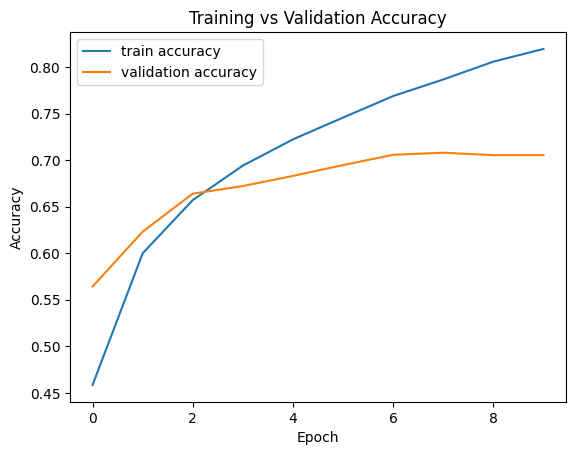

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

print("Loading CIFAR-10 dataset...")

# Load dataset
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize images
x_train = x_train / 255.0
x_test = x_test / 255.0

# Class names
class_names = [
'airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck'
]

print("Dataset loaded successfully")

# -----------------------------
# Build CNN Model
# -----------------------------

model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))

model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))

model.add(layers.Dense(10, activation='softmax'))

# -----------------------------
# Compile Model
# -----------------------------

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training started...")

# -----------------------------
# Train Model
# -----------------------------

history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

# -----------------------------
# Evaluate Model
# -----------------------------

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

# -----------------------------
# Plot Training Performance
# -----------------------------

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.title("Training vs Validation Accuracy")

plt.show()